# 01 - Exploratory Data Analysis & Preprocessing

**Lending Club credit-risk project.** This notebook covers exploratory data analysis and leakage-free preprocessing on the Lending Club loan dataset.

Key design decisions:
- **Real loan data** (2.26M Lending Club loans) with a binary target from `loan_status`.
- **Target definition:** 1 = Charged Off / Default, 0 = Fully Paid; unresolved loans (Current / Late / In Grace Period) are dropped.
- **Origination-time feature allowlist:** only columns known at loan origination are used as features. Outcome/economics columns (`funded_amnt`, `total_pymnt`, `recoveries`, ...) are reserved for the profit layer in notebook 03.
- **Learned transforms deferred to Pipeline:** imputation, scaling, MI selection, and SMOTE are fit on training data only inside the modeling Pipeline (notebook 02).


In [43]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))  # so `src` is importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import data as D
from src import features as F

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)

# Color helper: maps actual default-rate values to RdYlGn_r colors
# Normalizes from actual min→max so the lowest bar is green and highest is red
def _rate_colors(vals, vmin=None, vmax=None):
    import matplotlib.colors as _mc
    vals = list(vals)
    spread = max(vals) - min(vals)
    pad = spread * 0.15 if spread > 0 else 0.01
    _vmin = vmin if vmin is not None else min(vals) - pad
    _vmax = vmax if vmax is not None else max(vals) + pad
    norm = _mc.Normalize(vmin=_vmin, vmax=_vmax)
    return [plt.cm.RdYlGn_r(norm(v)) for v in vals]

## 1. Load data and define the target

We read only the columns we need (memory-friendly on the 1.19 GB file), map `loan_status` to a binary target, and keep only **resolved** loans. We use a stratified sample here for fast EDA; the full ~1.3M resolved loans are used for final training.

In [44]:
raw = D.load_raw()
print(f"Raw resolved-or-not rows: {len(raw):,}, columns read: {raw.shape[1]}")

df = D.make_target(raw)
print(f"Resolved loans: {len(df):,}")
print(df[C.TARGET].value_counts().rename("count"))
print("Default rate:", round(df[C.TARGET].mean(), 4))

# Stratified sample for interactive EDA
df = D.stratified_sample(df, 60_000)
print("EDA sample:", df.shape)

Raw resolved-or-not rows: 2,260,668, columns read: 32
Resolved loans: 1,306,387
target
0    1043940
1     262447
Name: count, dtype: int64
Default rate: 0.2009
EDA sample: (60000, 33)


In [47]:
raw

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,total_pymnt,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,application_type,mort_acc,pub_rec_bankruptcies
0,2500,2500,36 months,13.56,84.92,C,C1,10+ years,RENT,55000.0,Not Verified,Current,debt_consolidation,NY,18.24,0.0,Apr-2001,1.0,9.0,1.0,4341,10.3,34.0,w,167.020000,113.98,53.04,0.0,0.0,Individual,0.0,1.0
1,30000,30000,60 months,18.94,777.23,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,Current,debt_consolidation,LA,26.52,0.0,Jun-1987,0.0,13.0,1.0,12315,24.2,44.0,w,1507.110000,612.25,894.86,0.0,0.0,Individual,3.0,1.0
2,5000,5000,36 months,17.97,180.69,D,D1,6 years,MORTGAGE,59280.0,Source Verified,Current,debt_consolidation,MI,10.51,0.0,Apr-2011,0.0,8.0,0.0,4599,19.1,13.0,w,353.890000,212.79,141.10,0.0,0.0,Individual,2.0,0.0
3,4000,4000,36 months,18.94,146.51,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,Current,debt_consolidation,WA,16.74,0.0,Feb-2006,0.0,10.0,0.0,5468,78.1,13.0,w,286.710000,168.07,118.64,0.0,0.0,Individual,3.0,0.0
4,30000,30000,60 months,16.14,731.78,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,Current,debt_consolidation,MD,26.35,0.0,Dec-2000,0.0,12.0,0.0,829,3.6,26.0,w,1423.210000,660.98,762.23,0.0,0.0,Individual,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,12000,12000,60 months,14.08,279.72,C,C3,10+ years,MORTGAGE,58000.0,Not Verified,Current,debt_consolidation,VT,20.88,0.0,Jan-2004,0.0,12.0,0.0,9592,39.2,34.0,w,5360.960000,3312.80,2048.16,0.0,0.0,Individual,2.0,0.0
2260664,12000,12000,60 months,25.82,358.01,E,E4,< 1 year,MORTGAGE,30000.0,Not Verified,Fully Paid,debt_consolidation,OR,19.28,3.0,Mar-2003,1.0,10.0,0.0,3497,20.2,26.0,w,14499.802172,12000.00,2499.80,0.0,0.0,Joint App,4.0,0.0
2260665,10000,10000,36 months,11.99,332.10,B,B5,10+ years,OWN,64000.0,Source Verified,Current,debt_consolidation,IL,12.96,0.0,Feb-1995,0.0,6.0,0.0,7094,70.9,13.0,w,5306.940000,4006.73,1300.21,0.0,0.0,Individual,3.0,0.0
2260666,12000,12000,60 months,21.45,327.69,D,D5,NaN,RENT,60000.0,Not Verified,Current,debt_consolidation,AK,30.82,2.0,Jul-2003,1.0,8.0,0.0,12927,34.9,17.0,w,5207.290000,2075.31,3131.98,0.0,0.0,Individual,0.0,0.0


In [46]:
raw['term'].value_counts()

term
 36 months    1609754
 60 months     650914
Name: count, dtype: int64

In [3]:
raw['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

## 2. Class Balance

Credit default is a **minority-class** problem (~20% bad). This is why accuracy is not a reliable headline metric for this task — a trivial model that predicts every loan as good already achieves ~80% accuracy. We use ROC-AUC, KS statistic, and Gini as primary metrics. Class imbalance is addressed with SMOTE applied **inside training folds only** (see notebook 02).


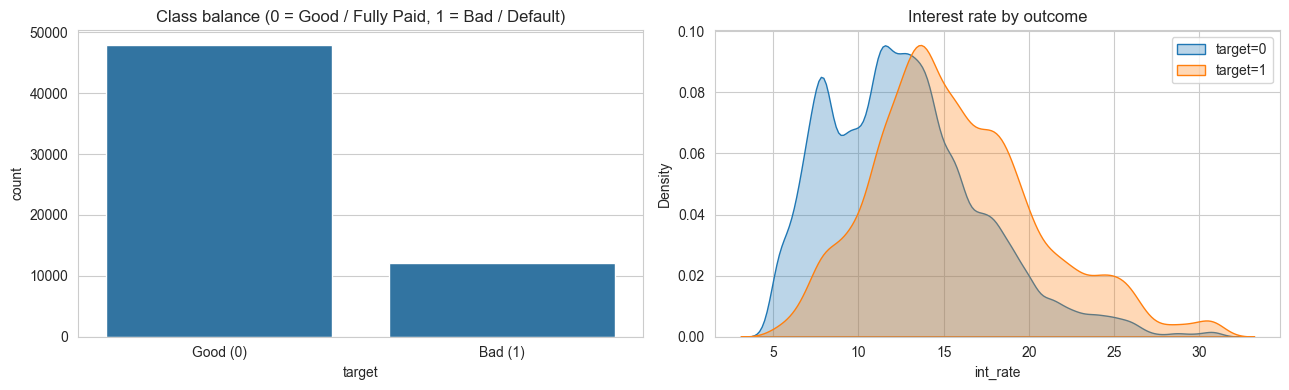

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x=C.TARGET, data=df, ax=ax[0])
ax[0].set_title("Class balance (0 = Good / Fully Paid, 1 = Bad / Default)")
ax[0].set_xticklabels(["Good (0)", "Bad (1)"])

for status, sub in df.groupby(C.TARGET):
    sns.kdeplot(sub["int_rate"], label=f"target={status}", ax=ax[1], fill=True, alpha=0.3)
ax[1].set_title("Interest rate by outcome")
ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Per-feature EDA (charge-off rate by category)

Comprehensive univariate and bivariate exploration of how default risk varies across the feature space. All analysis uses only **origination-time columns** (no post-origination leakage). The EDA is organized into the following subsections:

| Section | Topic |
|---|---|
| **Original** | Grade, Term, Home Ownership, Purpose |
| **3a** | Emp Length, Verification Status, Application Type, Initial List Status |
| **3b** | Numeric KDE distributions — Paid vs Defaulted |
| **3c** | Continuous binning: Loan Amount, DTI, Revolving Utilization |
| **3d** | Correlation heatmap of numeric features |
| **3e** | Interaction heatmaps: Grade × Term, Grade × Home Ownership |
| **3f** | Income-based segmentation: Income Quartile × Grade |
| **3g** | Geographic EDA: U.S. state-level default rates |
| **3h** | Credit risk signals: Delinquencies, Public Records, Inquiries |
| **3i** | Bivariate scatter: int_rate vs DTI, revol_util vs DTI |
| **3j** | Installment-to-Income affordability ratio |
| **3k** | Credit age from earliest_cr_line |
| **3l** | Defaulter volume composition (who drives losses) |

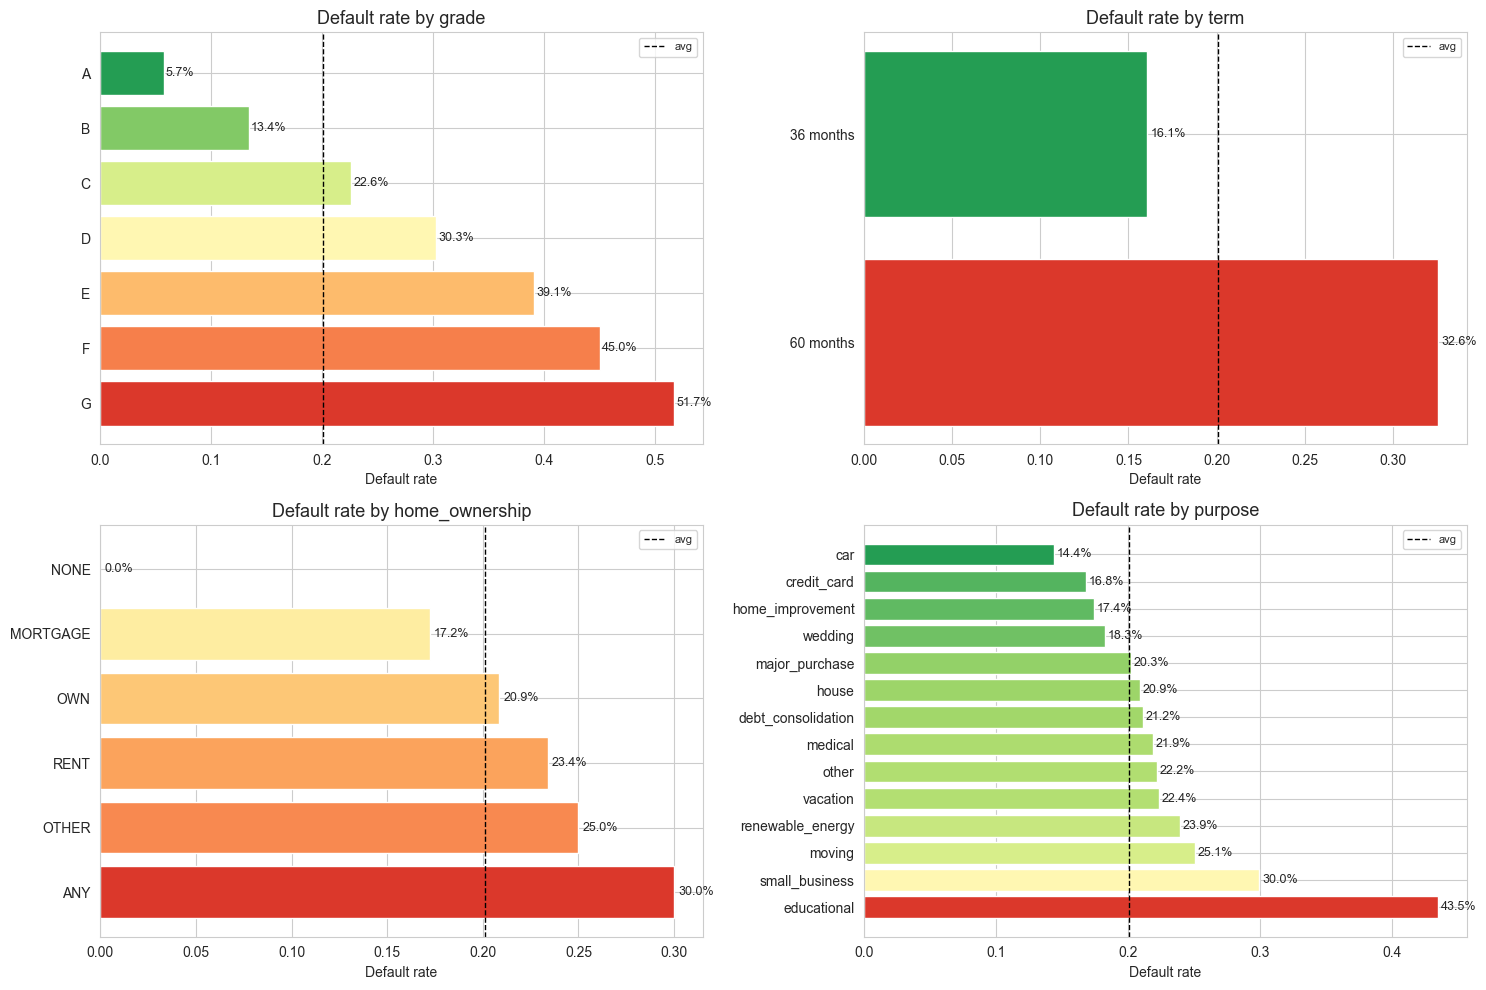

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(), ["grade", "term", "home_ownership", "purpose"]):
    rate = df.groupby(col)[C.TARGET].mean().sort_values(ascending=False)
    bars = ax.barh(rate.index, rate.values, color=_rate_colors(rate.values))
    ax.axvline(df[C.TARGET].mean(), ls='--', color='black', lw=1, label='avg')
    ax.set_title(f"Default rate by {col}", fontsize=13)
    ax.set_xlabel("Default rate")
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3a. More categorical features

Extending the per-category charge-off view to remaining categorical predictors: `emp_length`, `verification_status`, `application_type`, and `initial_list_status`.

**What to look for:** A counter-intuitive result appears in `verification_status` — "Verified" income applicants default at a *higher* rate than "Not Verified." This is a selection-bias dynamic: Lending Club verifies income specifically for applicants it flags as higher-risk. The feature is kept in the model because it captures useful information about LC's own risk-flagging process, but the direction of the relationship requires explanation when presenting to a non-technical audience.

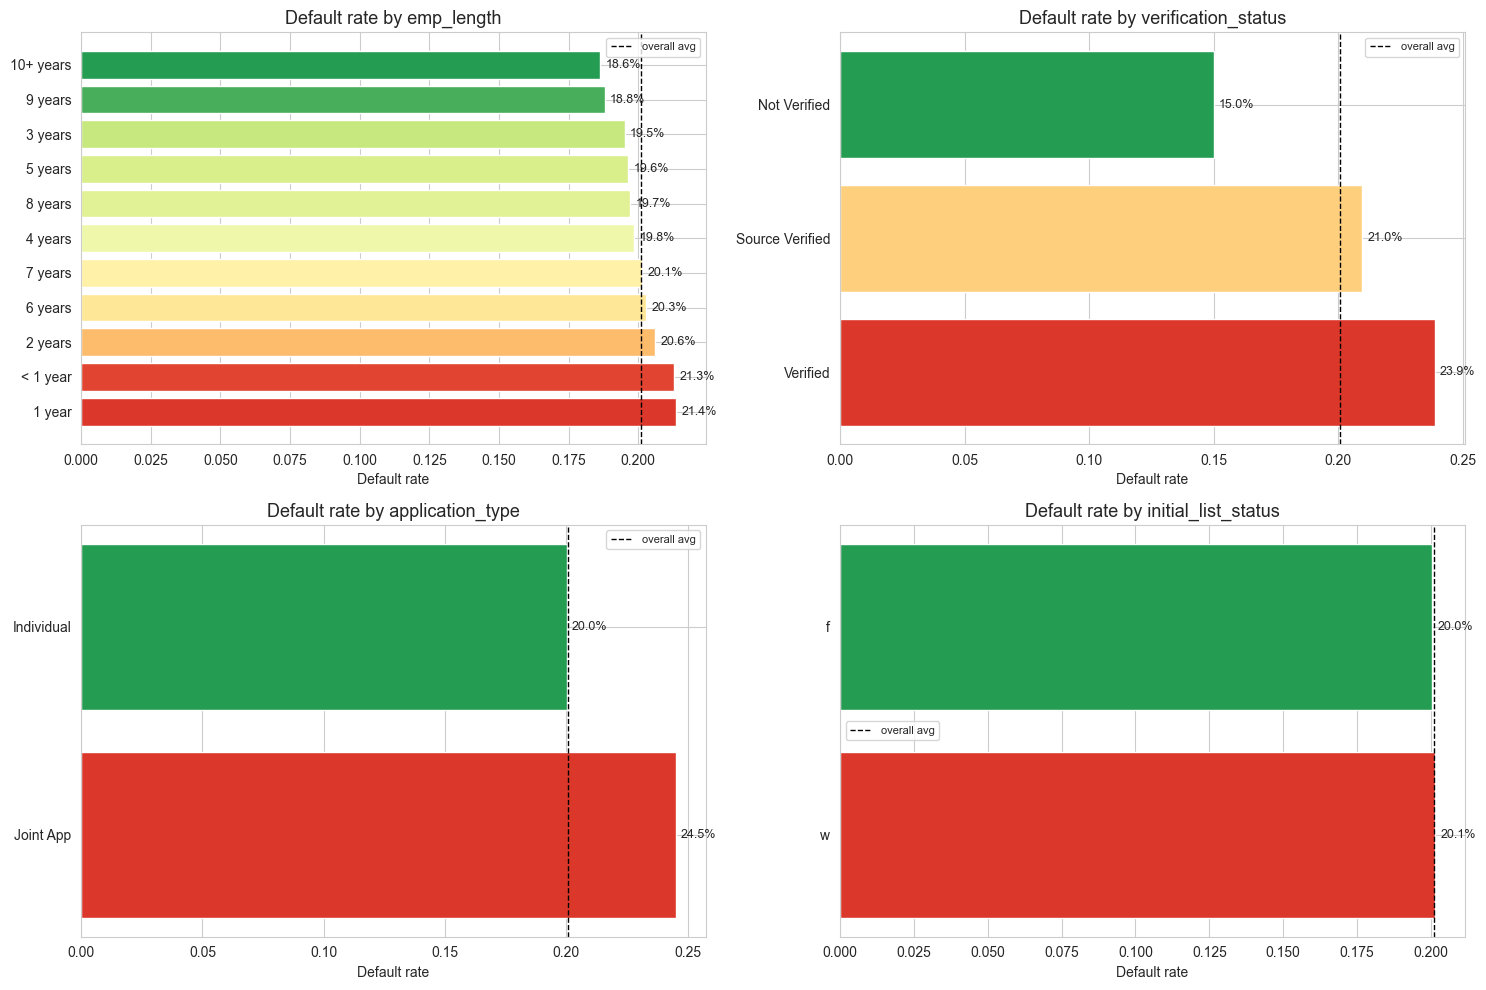

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(),
                   ["emp_length", "verification_status", "application_type", "initial_list_status"]):
    rate = df.groupby(col)[C.TARGET].mean().sort_values(ascending=False)
    bars = ax.barh(rate.index, rate.values, color=_rate_colors(rate.values))
    ax.set_title(f"Default rate by {col}", fontsize=13)
    ax.set_xlabel("Default rate")
    ax.axvline(df[C.TARGET].mean(), ls='--', color='black', lw=1, label='overall avg')
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3b. Numeric feature distributions — Default vs Non-Default

KDE plots split by `target` reveal where the two populations differ. Features with well-separated distributions are the strongest univariate signals.

**Key observations:**
- `int_rate`: Strongest visual separation — defaulted loans are concentrated at higher interest rates. However, this is excluded from the main model because it encodes Lending Club's own risk assessment, not an independent borrower signal.
- `dti`: Clear rightward shift for defaults — higher debt-to-income means higher risk.
- `revol_util`: Defaults skew toward higher revolving utilization.
- `annual_inc`: Defaults skew toward lower income (long right tail; capped at the 99th percentile for visualization clarity).
- `installment`: Moderately separated, but nearly collinear with `loan_amnt` — one will be dropped by the Pearson correlation step.

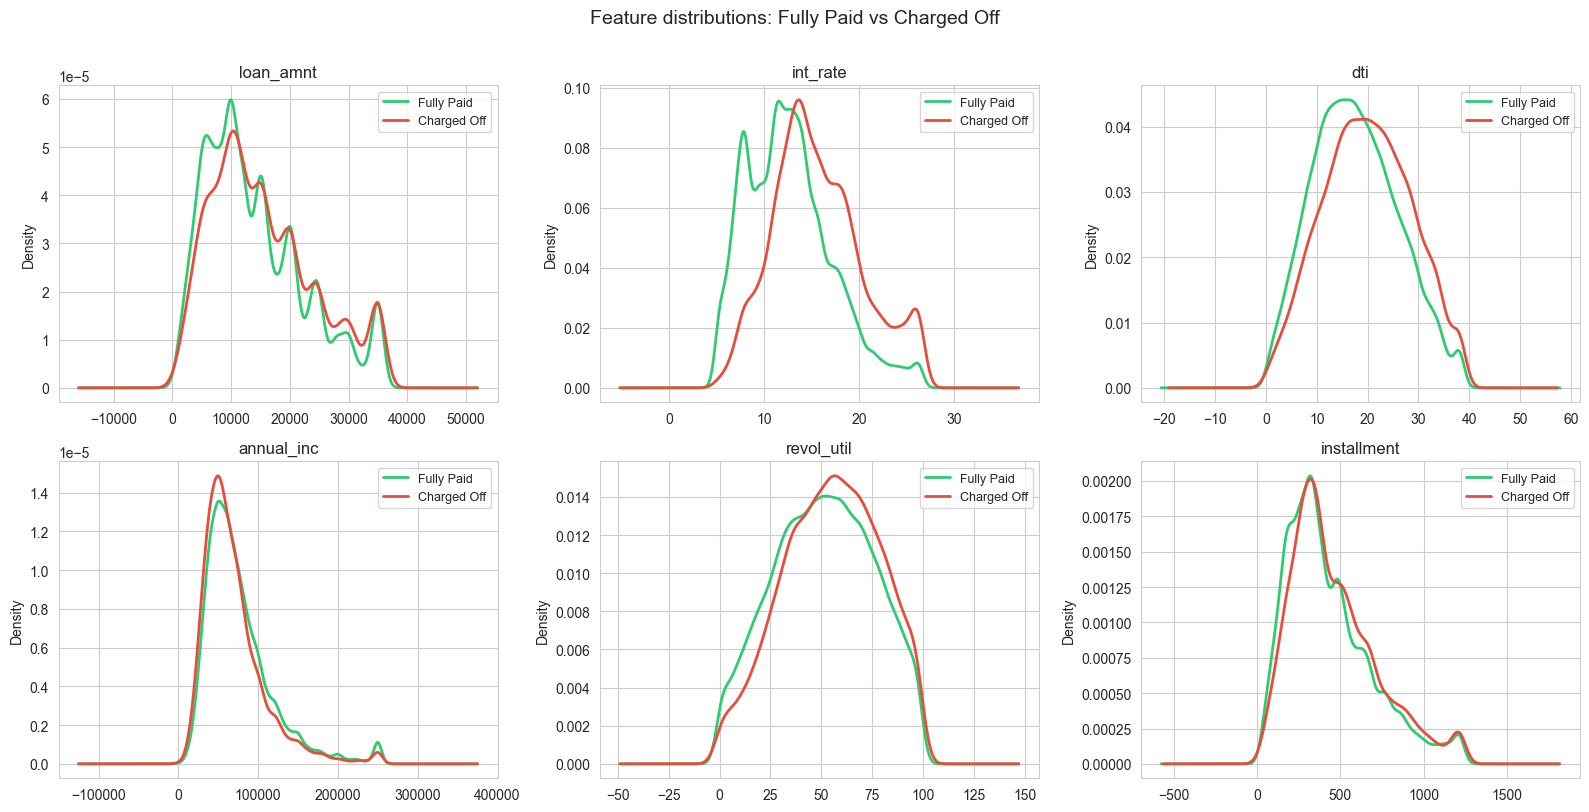

In [7]:
num_features = ["loan_amnt", "int_rate", "dti", "annual_inc", "revol_util", "installment"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
palette = {0: "#2ecc71", 1: "#e74c3c"}
labels  = {0: "Fully Paid", 1: "Charged Off"}

for ax, feat in zip(axes.ravel(), num_features):
    col_data = df[feat].clip(upper=df[feat].quantile(0.99))  # cap extreme outliers for clarity
    for tgt, grp in df.groupby(C.TARGET):
        grp_data = grp[feat].clip(upper=col_data.max())
        grp_data.dropna().plot.kde(ax=ax, label=labels[tgt], color=palette[tgt], lw=2)
    ax.set_title(feat, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Feature distributions: Fully Paid vs Charged Off", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

### 3c. Continuous feature binning — default rate by bucket

Binning continuous variables into quantile groups exposes **non-linear relationships** that Pearson correlation misses. A feature can have a low Pearson correlation with the target but still be highly informative if the relationship is monotonic but non-linear.

Here we look at `loan_amnt`, `dti`, and `revol_util`. All three show clean monotonic step-ups — the default rate rises consistently with each bucket. This shape is well-handled by tree-based models (XGBoost, Random Forest) and confirms these features deserve to be in the final model.

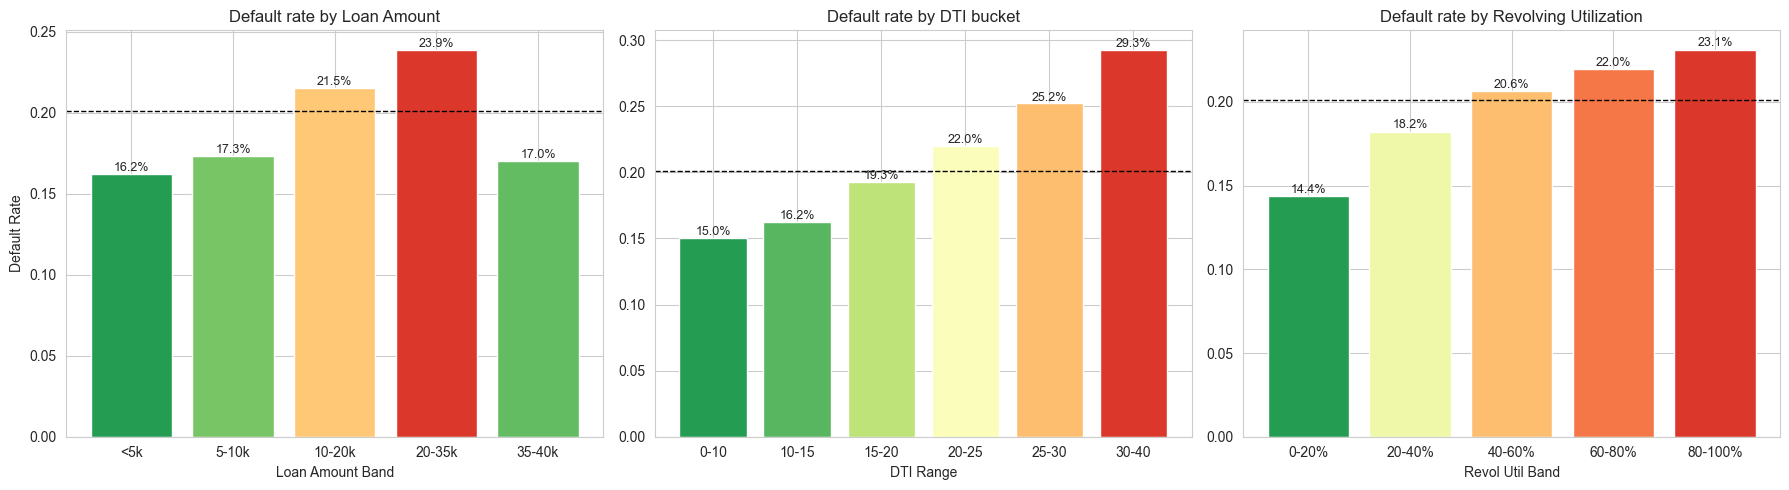

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── loan_amnt bins ──
df['loan_amnt_bin'] = pd.cut(df['loan_amnt'], bins=[0,5000,10000,20000,35000,40000],
                              labels=['<5k','5-10k','10-20k','20-35k','35-40k'])
rate_la = df.groupby('loan_amnt_bin', observed=True)[C.TARGET].mean()
axes[0].bar(rate_la.index.astype(str), rate_la.values,
            color=_rate_colors(rate_la.values))
axes[0].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
axes[0].set_title('Default rate by Loan Amount', fontsize=12)
axes[0].set_xlabel('Loan Amount Band')
axes[0].set_ylabel('Default Rate')
for i, v in enumerate(rate_la.values):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)

# ── DTI bins ──
df['dti_bin'] = pd.cut(df['dti'].clip(0, 40), bins=[0,10,15,20,25,30,40],
                        labels=['0-10','10-15','15-20','20-25','25-30','30-40'])
rate_dti = df.groupby('dti_bin', observed=True)[C.TARGET].mean()
axes[1].bar(rate_dti.index.astype(str), rate_dti.values,
            color=_rate_colors(rate_dti.values))
axes[1].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
axes[1].set_title('Default rate by DTI bucket', fontsize=12)
axes[1].set_xlabel('DTI Range')
for i, v in enumerate(rate_dti.values):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)

# ── revol_util bins ──
df['revol_util_bin'] = pd.cut(df['revol_util'].clip(0, 100),
                               bins=[0,20,40,60,80,100],
                               labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])
rate_rv = df.groupby('revol_util_bin', observed=True)[C.TARGET].mean()
axes[2].bar(rate_rv.index.astype(str), rate_rv.values,
            color=_rate_colors(rate_rv.values))
axes[2].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
axes[2].set_title('Default rate by Revolving Utilization', fontsize=12)
axes[2].set_xlabel('Revol Util Band')
for i, v in enumerate(rate_rv.values):
    axes[2].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()
df.drop(columns=['loan_amnt_bin','dti_bin','revol_util_bin'], inplace=True)

### 3d. Correlation heatmap (numeric features)

Pearson correlations among all numeric origination-time features. Highly correlated pairs (|r| > 0.95) are candidates for dropping — keeping both adds no information but increases noise and slows training.

**Key findings:**
- `loan_amnt` ↔ `installment`: |r| ≈ 0.95 — near-perfect collinearity. The `CorrelationThreshold` step in the Pipeline will drop one automatically at fit-time.
- `open_acc` ↔ `total_acc`: |r| ≈ 0.68 — related (total includes open) but not redundant enough to drop. Both are kept.
- Most other pairs: |r| < 0.3 — the feature set is largely orthogonal, which benefits both linear models and tree ensembles.

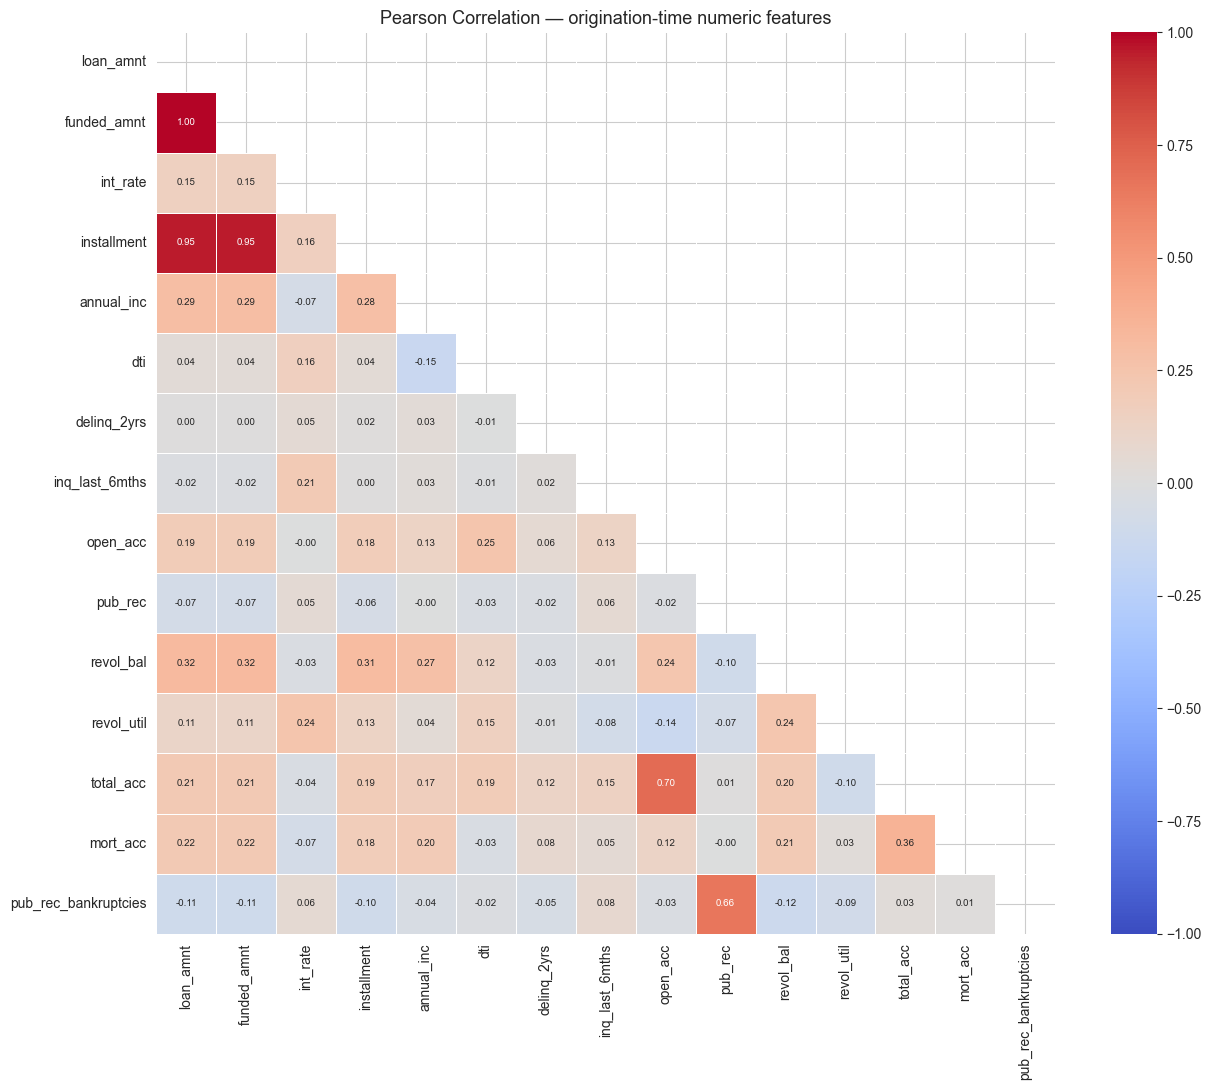

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclude post-origination economics columns
exclude = {'total_pymnt','total_rec_prncp','total_rec_int','recoveries',
           'collection_recovery_fee', C.TARGET}
num_cols = [c for c in num_cols if c not in exclude]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Pearson Correlation — origination-time numeric features', fontsize=13)
plt.tight_layout(); plt.show()

### 3e. Cross-feature interaction heatmaps

Single-feature charts miss interaction effects — situations where the combination of two features carries more information than either alone.

- **Grade × Term**: The 60-month default premium is not uniform — it amplifies with risk tier. A Grade-A 60-month loan adds only ~4pp of extra default risk vs 36-month; a Grade-G 60-month loan adds ~12pp. Tree-based models capture these interactions naturally through their split logic, without needing explicit engineered interaction features.
- **Grade × Home Ownership**: Mortgage ownership reduces default risk across all grades, but the risk reduction is proportionally larger in lower grades — housing stability moderates credit risk more meaningfully for already-risky borrowers.

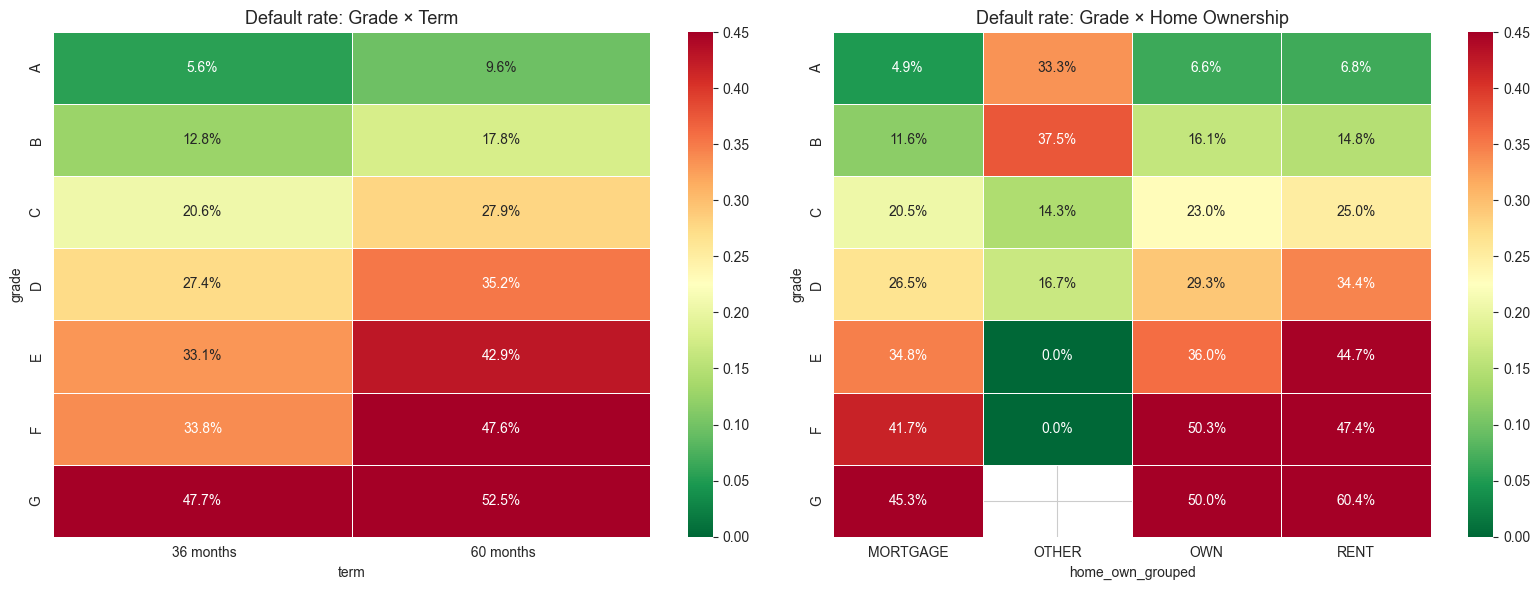

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grade × Term
pivot_gt = df.pivot_table(values=C.TARGET, index='grade', columns='term', aggfunc='mean')
sns.heatmap(pivot_gt, annot=True, fmt='.1%', cmap='RdYlGn_r',
            vmin=0, vmax=0.45, ax=axes[0], linewidths=0.5)
axes[0].set_title('Default rate: Grade × Term', fontsize=13)

# Grade × Home Ownership (collapse rare categories first)
df['home_own_grouped'] = df['home_ownership'].replace({'ANY': 'OTHER', 'NONE': 'OTHER'})
pivot_gh = df.pivot_table(values=C.TARGET, index='grade',
                           columns='home_own_grouped', aggfunc='mean')
sns.heatmap(pivot_gh, annot=True, fmt='.1%', cmap='RdYlGn_r',
            vmin=0, vmax=0.45, ax=axes[1], linewidths=0.5)
axes[1].set_title('Default rate: Grade × Home Ownership', fontsize=13)

plt.tight_layout(); plt.show()
df.drop(columns=['home_own_grouped'], inplace=True)

### 3f. Income-based customer segmentation

Splitting borrowers into **income quartiles** and crossing with **grade** reveals whether income independently modulates credit risk within a grade tier — a key lens for customer segmentation.

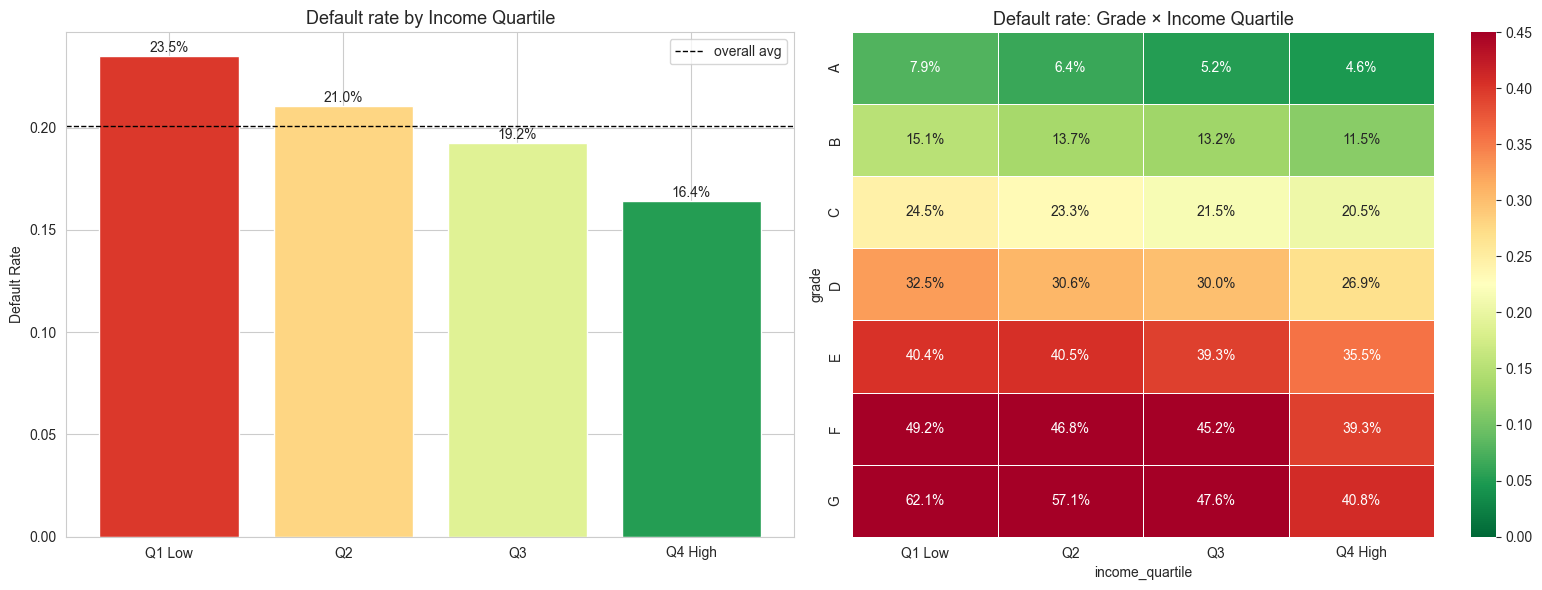

In [11]:
df['income_quartile'] = pd.qcut(df['annual_inc'].clip(upper=df['annual_inc'].quantile(0.99)),
                                  q=4, labels=['Q1 Low','Q2','Q3','Q4 High'])

# 3f-i: Default rate by income quartile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rate_inc = df.groupby('income_quartile', observed=True)[C.TARGET].mean()
axes[0].bar(rate_inc.index.astype(str), rate_inc.values,
            color=_rate_colors(rate_inc.values))
axes[0].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1, label='overall avg')
axes[0].set_title('Default rate by Income Quartile', fontsize=13)
axes[0].set_ylabel('Default Rate')
for i, v in enumerate(rate_inc.values):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=10)
axes[0].legend()

# 3f-ii: Grade × Income quartile heatmap
pivot_gi = df.pivot_table(values=C.TARGET, index='grade',
                           columns='income_quartile', aggfunc='mean', observed=True)
sns.heatmap(pivot_gi, annot=True, fmt='.1%', cmap='RdYlGn_r',
            vmin=0, vmax=0.45, ax=axes[1], linewidths=0.5)
axes[1].set_title('Default rate: Grade × Income Quartile', fontsize=13)

plt.tight_layout(); plt.show()
df.drop(columns=['income_quartile'], inplace=True)

### 3g. Geographic EDA — default rate by U.S. state

State can proxy for local economic conditions, unemployment cycles, and bankruptcy laws. We show the 10 highest and 10 lowest default-rate states (minimum 100 resolved loans).

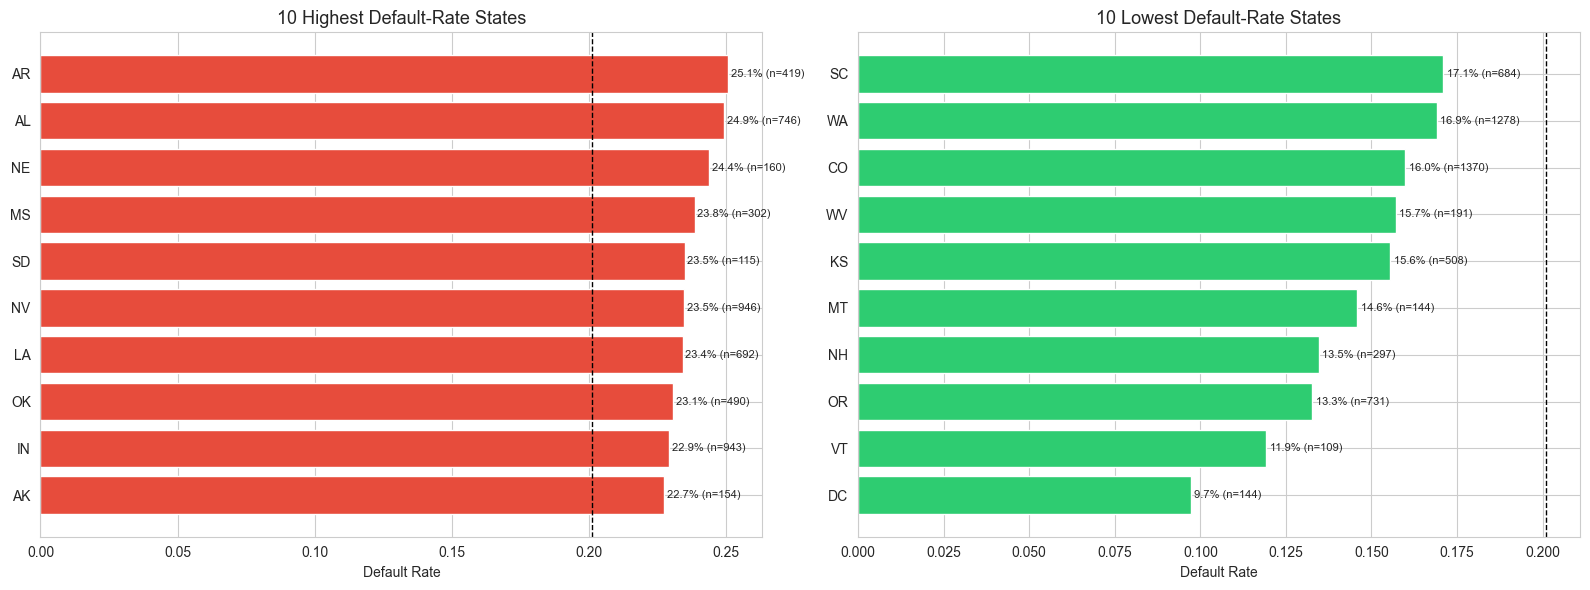

In [12]:
state_stats = (df.groupby('addr_state')[C.TARGET]
                 .agg(['mean','count'])
                 .rename(columns={'mean':'default_rate','count':'n'})
                 .query('n >= 100')
                 .sort_values('default_rate'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_bad  = state_stats.tail(10)
top10_good = state_stats.head(10)

axes[0].barh(top10_bad.index, top10_bad['default_rate'], color='#e74c3c')
axes[0].set_title('10 Highest Default-Rate States', fontsize=13)
axes[0].set_xlabel('Default Rate')
axes[0].axvline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
for i, (idx, row) in enumerate(top10_bad.iterrows()):
    axes[0].text(row['default_rate']+0.001, i, f"{row['default_rate']:.1%} (n={row['n']:.0f})",
                 va='center', fontsize=8)

axes[1].barh(top10_good.index, top10_good['default_rate'], color='#2ecc71')
axes[1].set_title('10 Lowest Default-Rate States', fontsize=13)
axes[1].set_xlabel('Default Rate')
axes[1].axvline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
for i, (idx, row) in enumerate(top10_good.iterrows()):
    axes[1].text(row['default_rate']+0.001, i, f"{row['default_rate']:.1%} (n={row['n']:.0f})",
                 va='center', fontsize=8)

plt.tight_layout(); plt.show()

### 3h. Credit risk signal EDA

Derogatory marks (`delinq_2yrs`, `pub_rec`, `inq_last_6mths`) are classic red flags. We cap counts at 3+ to avoid sparse extreme bins and plot default rate vs count.

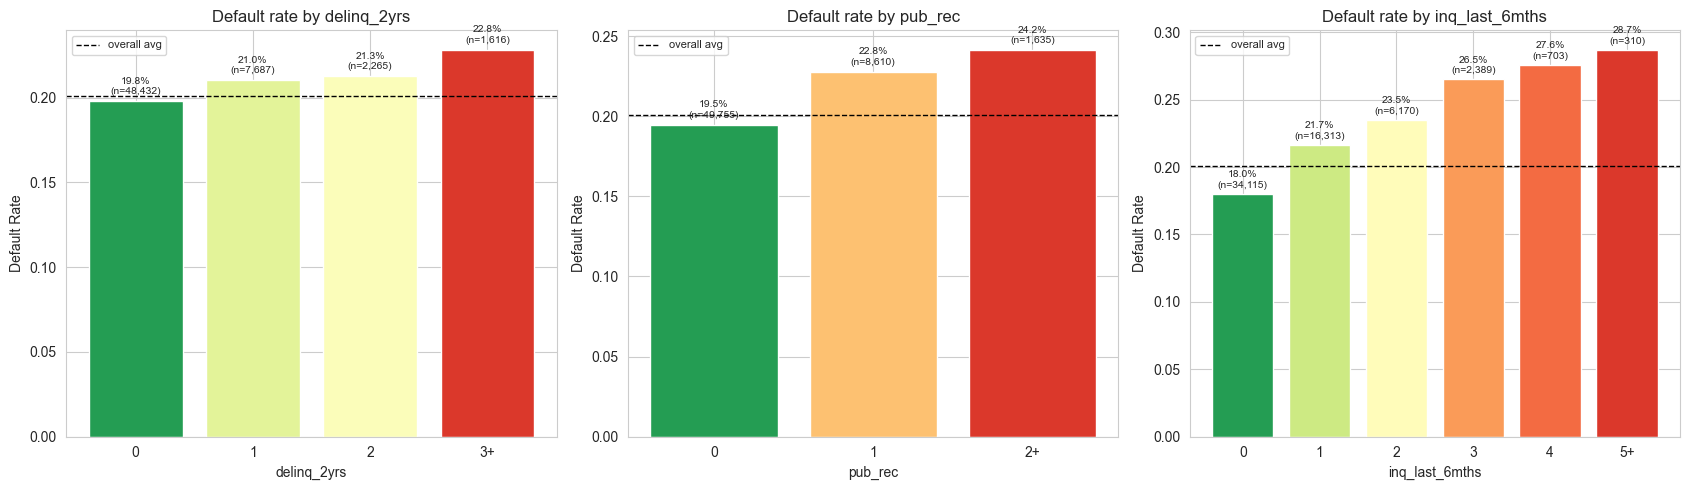

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, cap in zip(axes,
                         ['delinq_2yrs', 'pub_rec', 'inq_last_6mths'],
                         [3, 2, 5]):
    tmp = df[col].clip(upper=cap).fillna(0).astype(int)
    rate = df[C.TARGET].groupby(tmp).mean()
    counts = tmp.value_counts().sort_index()
    label_map = {v: (str(v) if v < cap else f'{cap}+') for v in rate.index}
    x_labels = [label_map[v] for v in rate.index]
    bars = ax.bar(x_labels, rate.values,
                  color=_rate_colors(rate.values))
    ax.axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1, label='overall avg')
    ax.set_title(f'Default rate by {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Default Rate')
    ax.legend(fontsize=8)
    # Annotate with sample counts
    for bar, val, cnt in zip(bars, rate.values, counts.reindex(rate.index, fill_value=0)):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.003, f'{val:.1%}\n(n={cnt:,})',
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout(); plt.show()

### 3i. Bivariate scatter — interest rate vs. DTI colored by default

A 2D density view of the two strongest continuous risk signals. Defaulted loans tend to cluster toward **higher int_rate AND higher DTI**. The bottom-left quadrant (low rate, low DTI) is the safest lending zone.

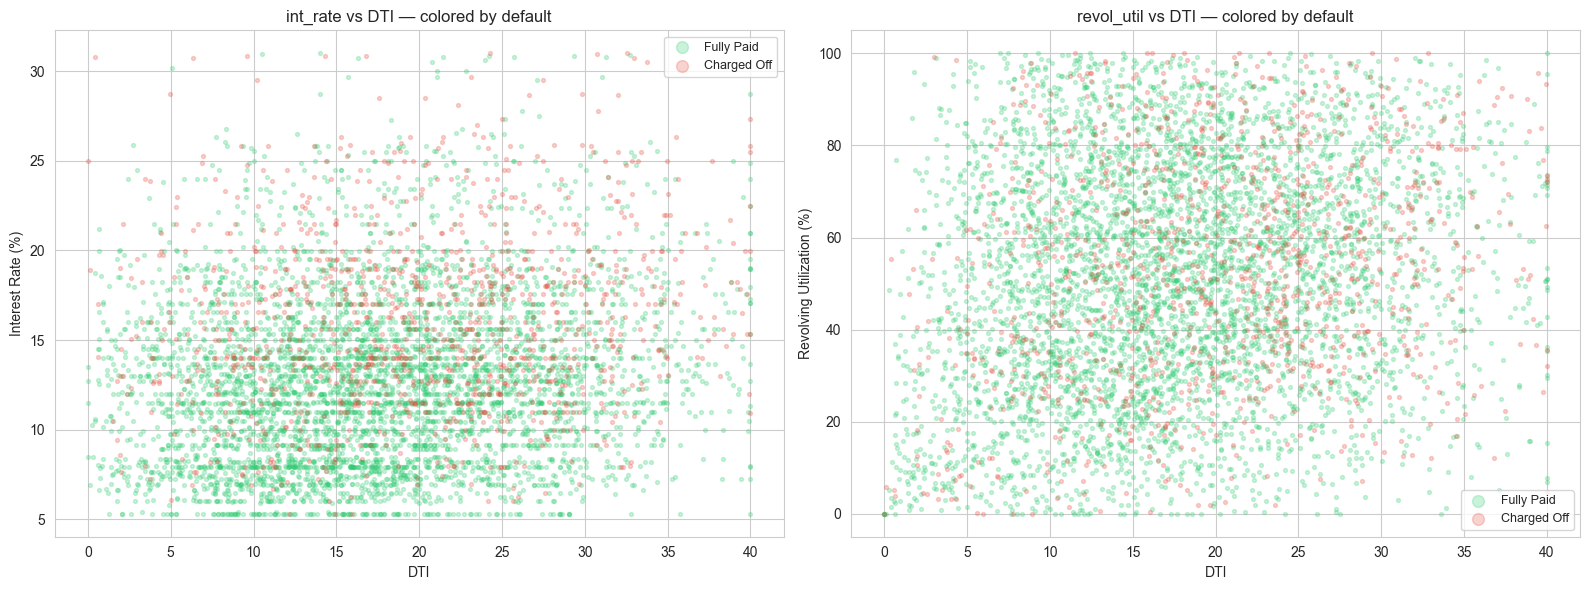

In [14]:
sample = df.sample(min(6000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: int_rate vs dti scatter
for tgt, grp in sample.groupby(C.TARGET):
    lbl = 'Charged Off' if tgt == 1 else 'Fully Paid'
    col = '#e74c3c' if tgt == 1 else '#2ecc71'
    axes[0].scatter(grp['dti'].clip(0, 40), grp['int_rate'],
                    alpha=0.25, s=8, color=col, label=lbl)
axes[0].set_xlabel('DTI')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('int_rate vs DTI — colored by default', fontsize=12)
axes[0].legend(markerscale=3, fontsize=9)

# Panel 2: revol_util vs dti scatter
for tgt, grp in sample.groupby(C.TARGET):
    lbl = 'Charged Off' if tgt == 1 else 'Fully Paid'
    col = '#e74c3c' if tgt == 1 else '#2ecc71'
    axes[1].scatter(grp['dti'].clip(0, 40), grp['revol_util'].clip(0, 100),
                    alpha=0.25, s=8, color=col, label=lbl)
axes[1].set_xlabel('DTI')
axes[1].set_ylabel('Revolving Utilization (%)')
axes[1].set_title('revol_util vs DTI — colored by default', fontsize=12)
axes[1].legend(markerscale=3, fontsize=9)

plt.tight_layout(); plt.show()

### 3j. Customer segments: Installment-to-Income ratio

A borrower's **monthly installment as a share of monthly income** is a direct measure of affordability burden:

```
install_to_inc = installment / (annual_inc / 12)
```

Neither `installment` nor `annual_inc` alone captures this — a $500/month payment is very different for someone earning $30k/year versus $200k/year. The ratio combines them into a single affordability signal.

The EDA below shows a strong, monotonic relationship: default rate rises from ~14% at <2% burden to ~33% at >10% burden — more than double the base rate. This makes it a strong candidate for an explicit engineered feature in `features.py` for the next model iteration.

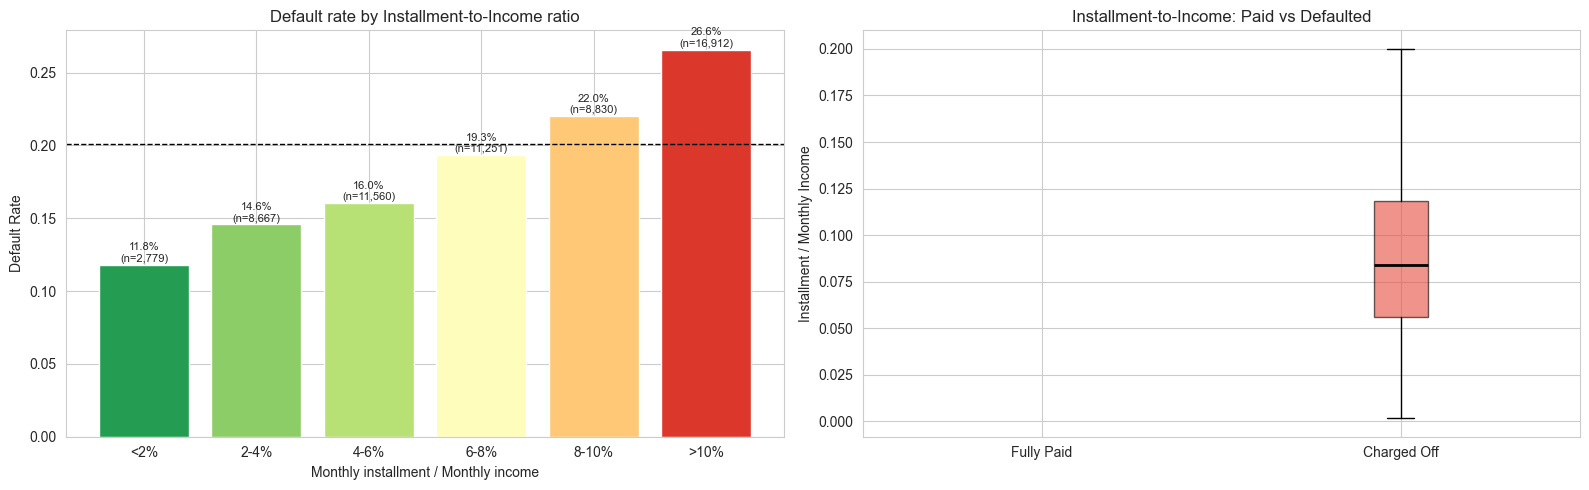

In [15]:
df['install_to_inc'] = df['installment'] / (df['annual_inc'] / 12)

df['install_bin'] = pd.cut(
    df['install_to_inc'].clip(0, 0.25),
    bins=[0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.25],
    labels=['<2%','2-4%','4-6%','6-8%','8-10%','>10%']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Default rate by installment/income bucket
rate_ii = df.groupby('install_bin', observed=True)[C.TARGET].mean()
cnt_ii  = df.groupby('install_bin', observed=True)[C.TARGET].count()
axes[0].bar(rate_ii.index.astype(str), rate_ii.values,
            color=_rate_colors(rate_ii.values))
axes[0].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
axes[0].set_title('Default rate by Installment-to-Income ratio', fontsize=12)
axes[0].set_xlabel('Monthly installment / Monthly income')
axes[0].set_ylabel('Default Rate')
for i, (v, n) in enumerate(zip(rate_ii.values, cnt_ii.values)):
    axes[0].text(i, v + 0.002, f'{v:.1%}\n(n={n:,})', ha='center', fontsize=8)

# Box plot of install_to_inc by target
data_0 = df.loc[df[C.TARGET]==0, 'install_to_inc'].clip(0, 0.2)
data_1 = df.loc[df[C.TARGET]==1, 'install_to_inc'].clip(0, 0.2)
axes[1].boxplot([data_0, data_1], labels=['Fully Paid','Charged Off'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                medianprops=dict(color='black', lw=2))
axes[1].patches[1].set_facecolor('#e74c3c')
axes[1].set_ylabel('Installment / Monthly Income')
axes[1].set_title('Installment-to-Income: Paid vs Defaulted', fontsize=12)

plt.tight_layout(); plt.show()
df.drop(columns=['install_to_inc','install_bin'], inplace=True)

### 3k. Credit age analysis

`earliest_cr_line` records the date the borrower's oldest trade line was opened. The gap between that date and today is **credit age** — how long the borrower has been an active credit user.

Older credit histories consistently default less. A borrower with 25+ years of credit history defaults at roughly half the rate of someone with <5 years. This is a classic "length of credit history" signal from FICO scoring methodology.

**Current treatment:** `earliest_cr_line_year` (the raw year integer) is already in the feature set. A direct `credit_age` column — `snapshot_year − earliest_cr_line_year` — would be a stronger and more interpretable signal and is worth adding in a future iteration.

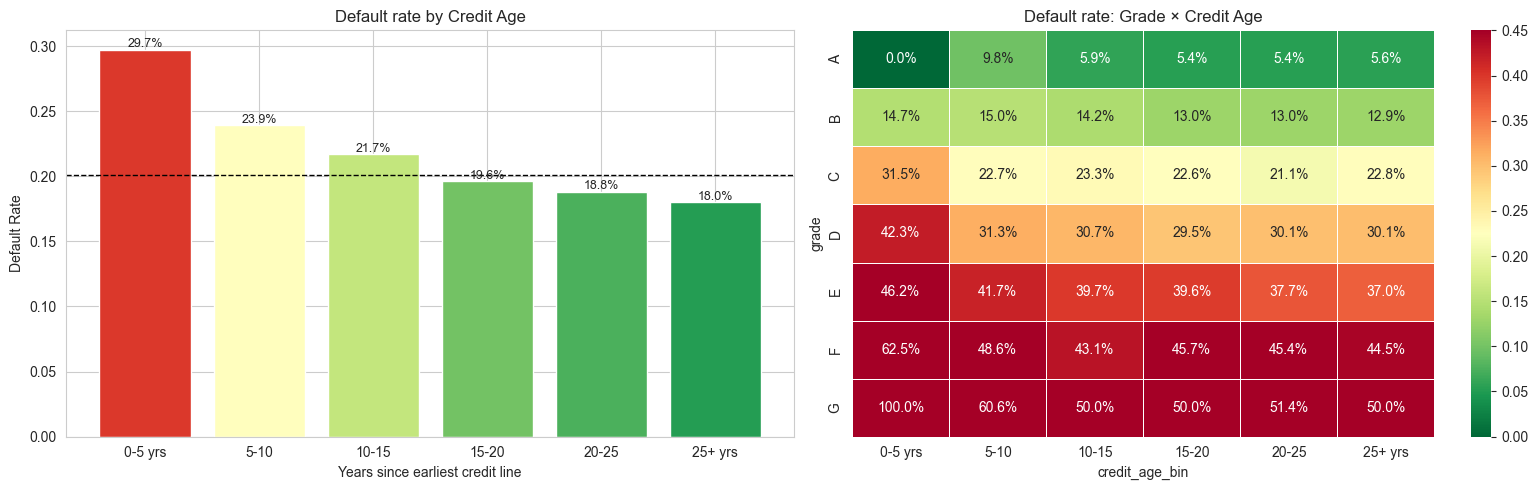

In [16]:
# Extract credit age at the time of data snapshot (approximated as 2018)
SNAPSHOT_YEAR = 2018
df['cr_line_year'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce').dt.year
df['credit_age']   = SNAPSHOT_YEAR - df['cr_line_year']

df['credit_age_bin'] = pd.cut(
    df['credit_age'].clip(0, 40),
    bins=[0, 5, 10, 15, 20, 25, 40],
    labels=['0-5 yrs','5-10','10-15','15-20','20-25','25+ yrs']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rate_ca = df.groupby('credit_age_bin', observed=True)[C.TARGET].mean()
cnt_ca  = df.groupby('credit_age_bin', observed=True)[C.TARGET].count()
axes[0].bar(rate_ca.index.astype(str), rate_ca.values,
            color=_rate_colors(rate_ca.values))
axes[0].axhline(df[C.TARGET].mean(), ls='--', color='black', lw=1)
axes[0].set_title('Default rate by Credit Age', fontsize=12)
axes[0].set_xlabel('Years since earliest credit line')
axes[0].set_ylabel('Default Rate')
for i, (v, n) in enumerate(zip(rate_ca.values, cnt_ca.values)):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)

# Grade × credit_age_bin heatmap — does credit age independently predict within a grade?
pivot_ca = df.pivot_table(values=C.TARGET, index='grade',
                           columns='credit_age_bin', aggfunc='mean', observed=True)
sns.heatmap(pivot_ca, annot=True, fmt='.1%', cmap='RdYlGn_r',
            vmin=0, vmax=0.45, ax=axes[1], linewidths=0.5)
axes[1].set_title('Default rate: Grade × Credit Age', fontsize=12)

plt.tight_layout(); plt.show()
df.drop(columns=['cr_line_year','credit_age','credit_age_bin'], inplace=True)

### 3l. Defaulter composition by purpose & grade

Understanding **who** defaults (not just the rate) is equally important. Stacked bars show what fraction of all charged-off loans come from each category — which segments drive the *volume* of losses, not just the probability.

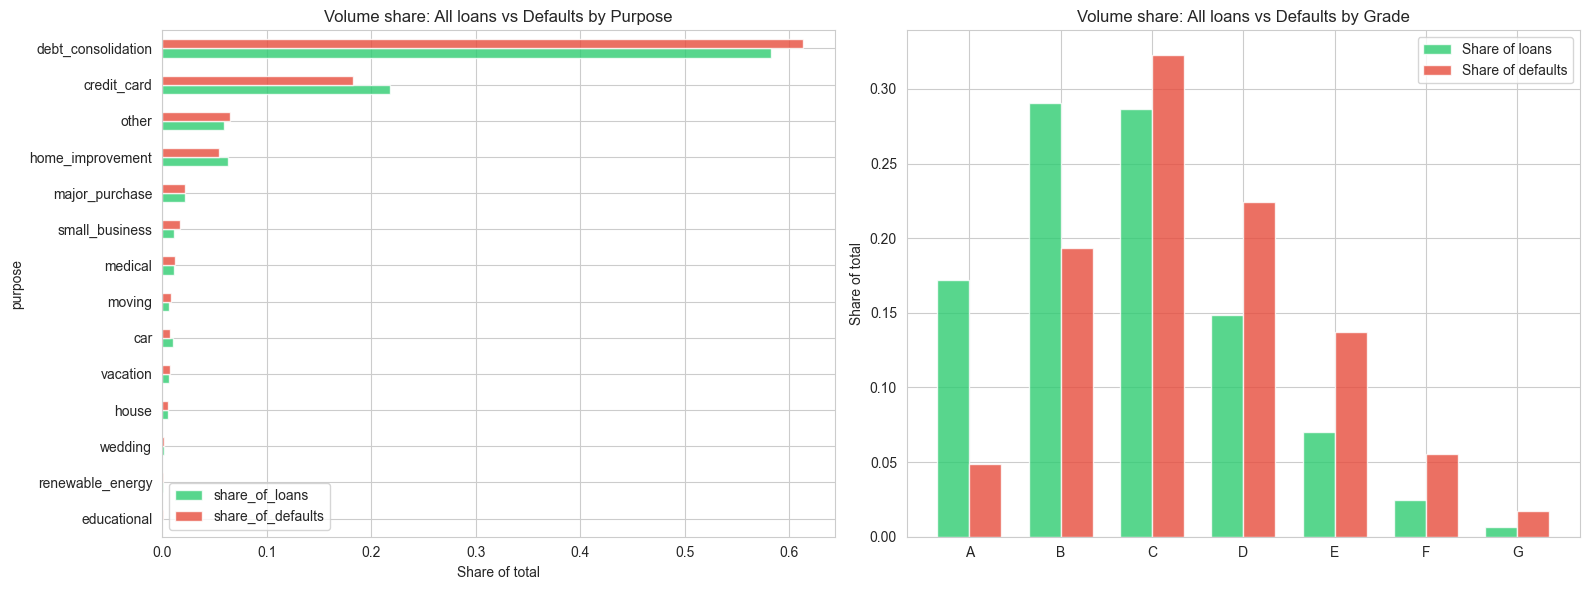

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Purpose: share of defaults vs share of loans
purpose_total   = df.groupby('purpose').size()
purpose_default = df[df[C.TARGET]==1].groupby('purpose').size()
purpose_df = pd.DataFrame({
    'share_of_loans':    purpose_total   / purpose_total.sum(),
    'share_of_defaults': purpose_default / purpose_default.sum()
}).sort_values('share_of_defaults', ascending=True).fillna(0)

purpose_df.plot.barh(ax=axes[0], color=['#2ecc71','#e74c3c'], alpha=0.8)
axes[0].set_title('Volume share: All loans vs Defaults by Purpose', fontsize=12)
axes[0].set_xlabel('Share of total')
axes[0].axvline(0, color='black', lw=0.5)

# Grade: share of defaults vs share of loans
grade_total   = df.groupby('grade').size()
grade_default = df[df[C.TARGET]==1].groupby('grade').size()
grade_df = pd.DataFrame({
    'share_of_loans':    grade_total   / grade_total.sum(),
    'share_of_defaults': grade_default / grade_default.sum()
}).sort_index().fillna(0)

x = np.arange(len(grade_df))
w = 0.35
axes[1].bar(x - w/2, grade_df['share_of_loans'],    w, label='Share of loans',    color='#2ecc71', alpha=0.8)
axes[1].bar(x + w/2, grade_df['share_of_defaults'], w, label='Share of defaults', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(grade_df.index)
axes[1].set_title('Volume share: All loans vs Defaults by Grade', fontsize=12)
axes[1].set_ylabel('Share of total')
axes[1].legend()

plt.tight_layout(); plt.show()

## 4. Cleaning & Feature Engineering

A key distinction in any ML pipeline: **some transforms are safe to apply before the train/test split, and some are not.**

A transform is safe *before* the split if it is **deterministic** — it applies a fixed, mechanical rule to each row in isolation. No statistic is computed from the data distribution, so the result for a row would be identical whether that row was in the training set or the test set.

`features.clean_frame` contains only these safe operations:

| Operation | Input → Output | Why it is safe before the split |
|---|---|---|
| `term` parsing | `' 36 months'` → `36` | Regex extracts a digit — no data distribution involved |
| `emp_length` mapping | `'10+ years'` → `10` | Hardcoded lookup table, same for every row unconditionally |
| `earliest_cr_line` parsing | `'Jan-2005'` → `2005` | Date parsing with a fixed format |
| Binarize `pub_rec`, `mort_acc`, `pub_rec_bankruptcies` | `count > 0` → `1`, else `0` | Fixed threshold (zero), not computed from data |
| Collapse `home_ownership` ANY/NONE → OTHER | String replace with a fixed rule | Hardcoded, does not observe frequency in the data |

### What does NOT belong here

Transforms that **learn a parameter from the data** must be deferred to the modeling Pipeline (notebook 02):

- **Median imputation** — the median is computed from the training distribution. Computing it on the full dataset and then imputing training rows would let test-set values influence what gets filled in training data.
- **StandardScaler** — mean and standard deviation are statistics learned from the data. Same principle.
- **Mutual Information selection** — MI scores are computed from the joint distribution of each feature and the target. Must be computed on training rows only.
- **Pearson correlation drop** — the correlation matrix is a statistic of the training data; which column gets dropped must be decided from training rows only.
- **SMOTE** — generates synthetic minority-class rows by interpolating between existing training examples. Must never touch the test set.

All of the above live inside `src/features.build_feature_pipeline()` and `src/resampling.build_model_pipeline()`, which are fit exclusively on the training fold inside each cross-validation split.

In [18]:
clean = F.clean_frame(df)
X, y = F.split_X_y(clean, include_grade=False)
print("Feature matrix:", X.shape)
print("Numeric + categorical features used:")
print(list(X.columns))
X.head()

Feature matrix: (60000, 22)
Numeric + categorical features used:
['loan_amnt', 'installment', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delinq_2yrs', 'inq_last_6mths', 'emp_length_num', 'term_months', 'earliest_cr_line_year', 'pub_rec_flag', 'mort_acc_flag', 'pub_rec_bankruptcies_flag', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'addr_state']


,loan_amnt,installment,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,delinq_2yrs,inq_last_6mths,emp_length_num,term_months,earliest_cr_line_year,pub_rec_flag,mort_acc_flag,pub_rec_bankruptcies_flag,home_ownership,verification_status,purpose,initial_list_status,application_type,addr_state
0,14000,464.94,100000.0,11.92,16.0,25375,53.8,29.0,3.0,0.0,10.0,36.0,1982.0,0,1,0,MORTGAGE,Not Verified,credit_card,f,Individual,WI
1,5000,175.77,95000.0,27.69,12.0,33374,70.3,25.0,0.0,0.0,10.0,36.0,1998.0,0,1,0,MORTGAGE,Source Verified,other,f,Individual,OK
2,5000,168.11,84000.0,4.17,4.0,8370,84.5,5.0,0.0,0.0,6.0,36.0,2008.0,0,1,0,MORTGAGE,Not Verified,home_improvement,f,Individual,FL
3,5000,166.20,40000.0,24.60,7.0,5224,46.6,20.0,0.0,0.0,10.0,36.0,1998.0,0,1,0,OWN,Source Verified,debt_consolidation,w,Individual,TX
4,12500,401.65,65000.0,15.00,10.0,10539,30.6,31.0,0.0,0.0,10.0,36.0,1995.0,0,0,0,RENT,Not Verified,credit_card,f,Individual,IL


## 5. Leakage Control

Leakage prevention is enforced at two levels: **column selection** and **transform ordering.**

### Level 1 — Feature allowlist (column leakage)

The most dangerous form of leakage in credit-risk modeling is accidentally including a column that was only recorded *after* the loan outcome was known. For example, `total_pymnt` (total payment received) is only knowable after the loan closes — it is a direct function of the outcome, not an input to the decision. Using it as a model feature would give the model future knowledge unavailable at the time of a real approval decision.

The allowlist in `src/config.py` is **opt-in, not opt-out.** Only the 22 columns explicitly listed in `NUMERIC_FEATURES` and `CATEGORICAL_FEATURES` ever reach the model. The raw CSV has 145 columns; none of the remaining 123 can silently slip in regardless of how the data loading code changes.

Economics columns — `funded_amnt` (EAD), `total_pymnt`, `recoveries`, `total_rec_prncp`, `total_rec_int` — are not discarded. They are quarantined and passed to the profit layer in notebook 03 to compute `EL = PD × LGD × EAD`. They just never appear in the PD model's feature matrix `X`.

### Level 2 — Pipeline fit order (transform leakage)

Even with the right columns, fitting a scaler or imputer on the full dataset (train + test combined) before splitting leaks distributional information about the test set into the training process.

The wrong sequence:
```
1. Compute medians on the whole dataset  →  fill NaNs
2. Fit StandardScaler on whole dataset   →  scale all rows
3. Split into train / test
4. Train model on train, evaluate on test  ← test rows already influenced steps 1 & 2
```

The correct sequence (enforced by `imblearn.Pipeline`):
```
1. Split data into train / test (stratified)
2. Pipeline.fit(X_train, y_train):
     a. Median imputer  — learns fill values from X_train only
     b. StandardScaler  — learns mean / std from X_train only
     c. CorrelationThreshold — computes Pearson matrix from X_train only
     d. SelectKBest (MI) — scores features against y_train only
     e. SMOTE — generates synthetic rows from X_train only
     f. Classifier — trains on the resampled training data
3. Pipeline.predict(X_test):
     — X_test is transformed using the statistics learned in step 2
     — X_test rows never influenced any of those statistics
```

The `CorrelationThreshold` is a custom sklearn-compatible transformer (`BaseEstimator + TransformerMixin`) so it obeys the same `.fit()` / `.transform()` contract as every other step in the Pipeline, ensuring the "which columns to drop" decision is made purely from training data.

The assertion below confirms Level 1 — no economics or leakage column is present in the feature matrix `X`.

In [19]:
forbidden = set(C.ECONOMICS_COLUMNS) | set(C.LEAKAGE_COLUMNS)
leaked = forbidden.intersection(X.columns)
assert not leaked, f"LEAKAGE: {leaked}"
print("PASS: no economics/leakage columns in the feature matrix.")

print("\nEconomics columns quarantined for the profit layer (notebook 03):")
print(F.get_economics(clean).columns.tolist())

PASS: no economics/leakage columns in the feature matrix.

Economics columns quarantined for the profit layer (notebook 03):
['funded_amnt', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries', 'collection_recovery_fee']
